In [1]:
!pip install cartopy # Esta línea es para instalar cartopy. En su PC sólo tendría que hacerlo una vez, con algo como "conda install -c conda-forge cartopy"
import cartopy.crs as ccrs
import cartopy.feature

In [2]:
#Cargamos las librerías
import numpy as np #Librería para operaciones numéricas
import matplotlib.pyplot as plt #Librería para generar gráficas

In [3]:
import xarray as xr #librería para el manejo de archivos NetCDF

In [4]:
# Y otras herramientas:
import os
import datetime
import pandas as pd

In [5]:
#Cargar y abrir  NetCDF
ifile = xr.open_dataset('era5land_t2m_1hly_202607.nc') # Se carga el archivo NetCDF
ifile # llamamos otra vez a ifile, para ver un resumen de lo que contiene

<xarray.Dataset> Size: 120MB
Dimensions:     (valid_time: 744, latitude: 201, longitude: 201)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2026-07-01 ... 2026-07-31T23:...
  * latitude    (latitude) float64 2kB 15.0 14.9 14.8 14.7 ... -4.8 -4.9 -5.0
  * longitude   (longitude) float64 2kB -85.0 -84.9 -84.8 ... -65.2 -65.1 -65.0
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 120MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-12T22:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
# Con base en la información anterior, seleccionamos parte de los datos:
t2m = (ifile.t2m) - 273.15 #Del archivo tomamos los datos la variable "t2m" y se convierten a °C
lat_t2m = ifile.latitude #tomamos los datos de la variable latitud
lon_t2m = ifile.longitude #tomamos los datos de la variable longitud
times = ifile.valid_time.values  # Lee los tiempos en formato original
dates = pd.to_datetime(times) # Convierte los tiempos a datetime

In [7]:
# Es instructivo ver la variable tiempo original:
times

array(['2026-07-01T00:00:00.000000000', '2026-07-01T01:00:00.000000000',
       '2026-07-01T02:00:00.000000000', '2026-07-01T03:00:00.000000000',
       '2026-07-01T04:00:00.000000000', '2026-07-01T05:00:00.000000000',
       '2026-07-01T06:00:00.000000000', '2026-07-01T07:00:00.000000000',
       '2026-07-01T08:00:00.000000000', '2026-07-01T09:00:00.000000000',
       '2026-07-01T10:00:00.000000000', '2026-07-01T11:00:00.000000000',
       '2026-07-01T12:00:00.000000000', '2026-07-01T13:00:00.000000000',
       '2026-07-01T14:00:00.000000000', '2026-07-01T15:00:00.000000000',
       '2026-07-01T16:00:00.000000000', '2026-07-01T17:00:00.000000000',
       '2026-07-01T18:00:00.000000000', '2026-07-01T19:00:00.000000000',
       '2026-07-01T20:00:00.000000000', '2026-07-01T21:00:00.000000000',
       '2026-07-01T22:00:00.000000000', '2026-07-01T23:00:00.000000000',
       '2026-07-02T00:00:00.000000000', '2026-07-02T01:00:00.000000000',
       '2026-07-02T02:00:00.000000000', '2026-07-02

In [8]:
#Y luego ver nuestra nueva variable de tiempos:
dates

DatetimeIndex(['2026-07-01 00:00:00', '2026-07-01 01:00:00',
               '2026-07-01 02:00:00', '2026-07-01 03:00:00',
               '2026-07-01 04:00:00', '2026-07-01 05:00:00',
               '2026-07-01 06:00:00', '2026-07-01 07:00:00',
               '2026-07-01 08:00:00', '2026-07-01 09:00:00',
               ...
               '2026-07-31 14:00:00', '2026-07-31 15:00:00',
               '2026-07-31 16:00:00', '2026-07-31 17:00:00',
               '2026-07-31 18:00:00', '2026-07-31 19:00:00',
               '2026-07-31 20:00:00', '2026-07-31 21:00:00',
               '2026-07-31 22:00:00', '2026-07-31 23:00:00'],
              dtype='datetime64[ns]', length=744, freq=None)

In [9]:
# Luego, podemos graficar un paso de tiempo particular, e.g.
# las 11:00 UTC (los datos originalmente vienen en UTC), del
# 20 de julio, de 2026 (nuestro archivo sólo tiene datos para julio 2026)
# Notar que las 11:00 UTC corresponden a las 6:00 HLC (Hora Local Colombia). HLC = UTC - 5

# A continuación, algo de código generado con IA para tal propósito:

# Define the specific date and time you want to plot
target_date_time = datetime.datetime(2026, 7, 20, 11, 0) # Year, Month, Day, Hour, Minute

# Find the index corresponding to the target_date_time in the 'dates' array
# We use np.where to find the index where the 'dates' array matches our target_date_time
# The first [0] gets the array of indices, and the second [0] gets the first (and likely only) index
idx = np.where(dates == target_date_time)[0][0]

# Select the t2m data for the identified time step
t2m_slice = t2m[idx, :, :]




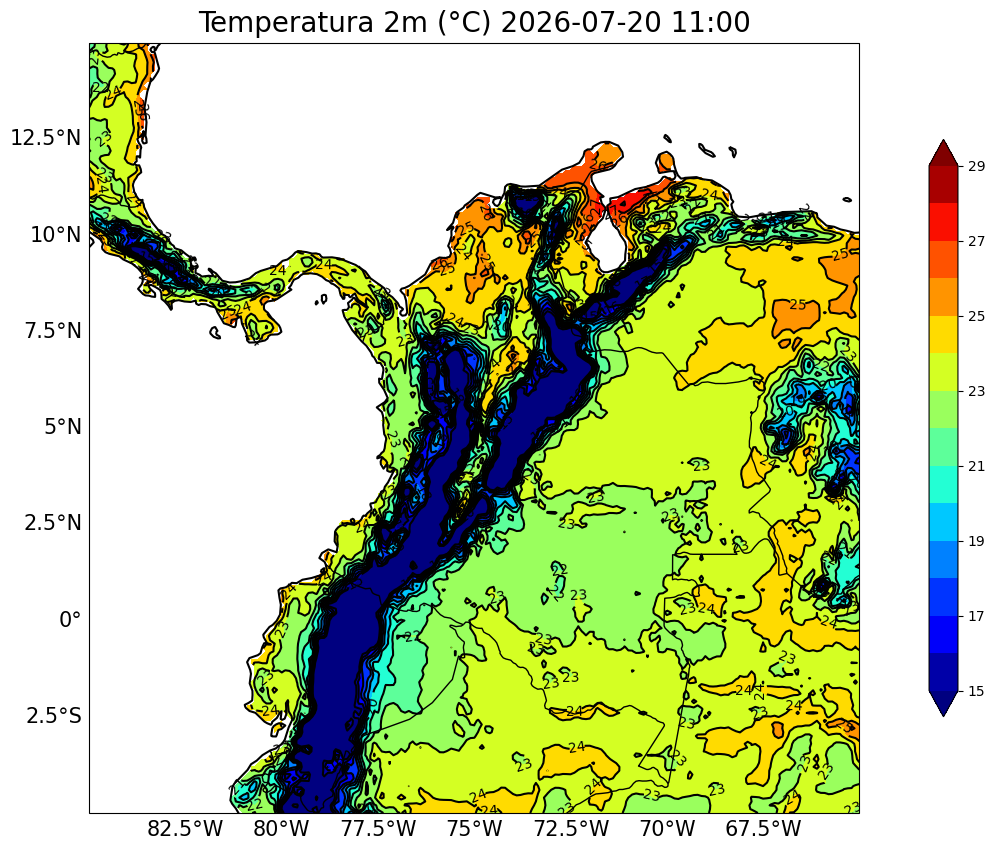

In [10]:
# Ahora, procedemos a graficar un primer mapa:

# Empezamos a hacer los mapas del periodo seleccionado, uno por uno:
fig = plt.figure(figsize=(18,10)) #Abrimos una hoja para pintar nuestro mapa y damos le tamaño a la hoja

ax = fig.add_subplot(projection=ccrs.PlateCarree()) #Indicamos que crearemos un mapa en nuestra hoja
#ax.set_extent([-10, -110, -13, 15]) #Se indican las coordenadas del mapa
ax.coastlines('50m',linewidth = 1.5) #se agregan los continentes
ax.add_feature(cartopy.feature.BORDERS) #Se agregan los países
niveles=np.arange(15,30,1) #Indicamos los valores que tomará la variable y el intervalo de paso
mapa = plt.contourf(lon_t2m, lat_t2m, t2m_slice,niveles,cmap="jet",extend='both') #Pintamos el mapa
contours=plt.contour(lon_t2m, lat_t2m, t2m_slice,niveles, colors="black",extend='both') #Agregamos los contornos
plt.clabel(contours, inline=1, fontsize=10, fmt="%i")
plt.clim = (15,30) #límites de la paleta de colores
plt.colorbar(mapa, orientation="vertical",shrink=0.75) #Agregamos la paleta de colores
plt.title(f'Temperatura 2m (°C) {target_date_time.strftime('%Y-%m-%d %H:%M')}', size=20, loc='center', pad=8) #Agregamos título al mapa


#Agregamos el grid
gl= ax.gridlines(color="black",draw_labels=True,linestyle="--")
#gl.xlabels_top=False #omitimos las etiquetas en la parte superior del mapa
gl.top_labels=False #omitimos las etiquetas en la parte superior del mapa
#gl.ylabels_right=False #omitimos las etiquetas en la parte derecha del mapa
gl.right_labels=False #omitimos las etiquetas en la parte derecha del mapa
gl.xlines=False #Omitimos las líneas de latitud
gl.ylines=False #Omitimos las líneas de longitud
gl.xlabel_style = {'size': 15} #Tamaño etiquetas eje X
gl.ylabel_style = {'size': 15} #Tamaño etiquetas eje Y

plt.show()
#plt.savefig('t2m_'  + yymo + '.png',dpi=300) #Guardamos la figura

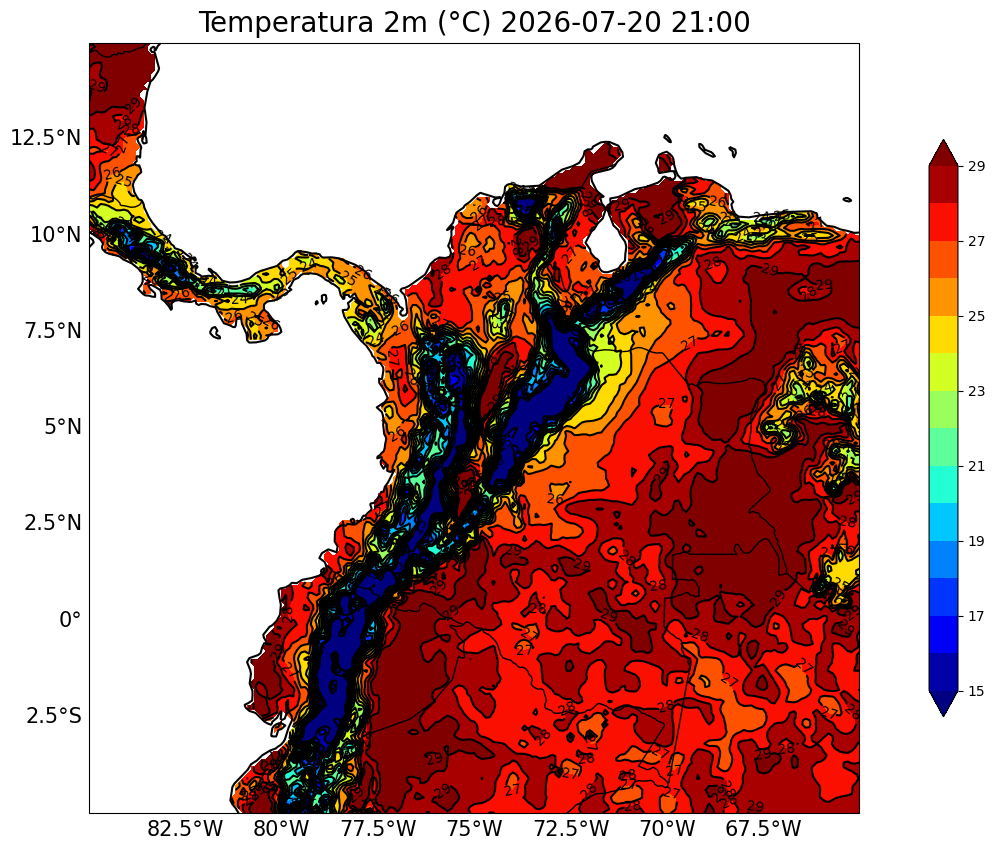

In [11]:


# Define the specific date and time you want to plot
target_date_time = datetime.datetime(2026, 7, 20, 21, 0) # Year, Month, Day, Hour, Minute
idx = np.where(dates == target_date_time)[0][0]
t2m_slice = t2m[idx, :, :]


fig = plt.figure(figsize=(18,10)) #Abrimos una hoja para pintar nuestro mapa y damos le tamaño a la hoja
ax = fig.add_subplot(projection=ccrs.PlateCarree()) #Indicamos que crearemos un mapa en nuestra hoja
#ax.set_extent([-10, -110, -13, 15]) #Se indican las coordenadas del mapa
ax.coastlines('50m',linewidth = 1.5) #se agregan los continentes
ax.add_feature(cartopy.feature.BORDERS) #Se agregan los países
niveles=np.arange(15,30,1) #Indicamos los valores que tomará la variable y el intervalo de paso
mapa = plt.contourf(lon_t2m, lat_t2m, t2m_slice,niveles,cmap="jet",extend='both') #Pintamos el mapa
contours=plt.contour(lon_t2m, lat_t2m, t2m_slice,niveles, colors="black",extend='both') #Agregamos los contornos
plt.clabel(contours, inline=1, fontsize=10, fmt="%i")
plt.clim = (15,30) #límites de la paleta de colores
plt.colorbar(mapa, orientation="vertical",shrink=0.75) #Agregamos la paleta de colores
plt.title(f'Temperatura 2m (°C) {target_date_time.strftime('%Y-%m-%d %H:%M')}', size=20, loc='center', pad=8) #Agregamos título al mapa

#Agregamos el grid
gl= ax.gridlines(color="black",draw_labels=True,linestyle="--")
#gl.xlabels_top=False #omitimos las etiquetas en la parte superior del mapa
gl.top_labels=False #omitimos las etiquetas en la parte superior del mapa
#gl.ylabels_right=False #omitimos las etiquetas en la parte derecha del mapa
gl.right_labels=False #omitimos las etiquetas en la parte derecha del mapa
gl.xlines=False #Omitimos las líneas de latitud
gl.ylines=False #Omitimos las líneas de longitud
gl.xlabel_style = {'size': 15} #Tamaño etiquetas eje X
gl.ylabel_style = {'size': 15} #Tamaño etiquetas eje Y

plt.show()


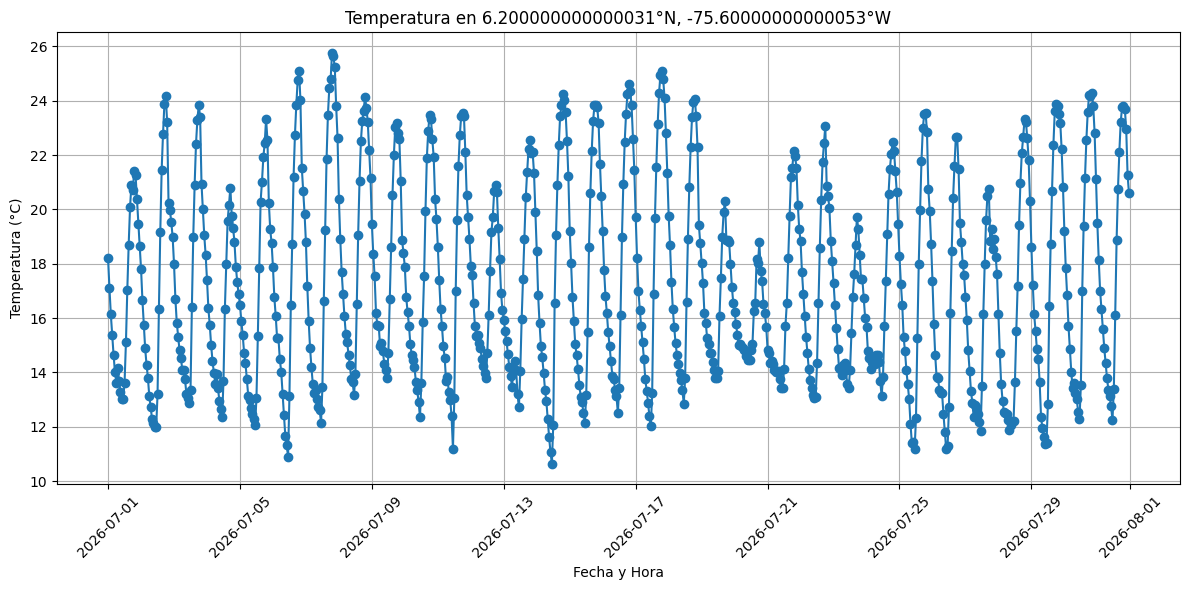

In [12]:
# Ahora, escojamos un único punto, y grafiquemos una serie de tiempo.

# Primer, escoger un lugar de interés:
lat1 = 6.24 # Latitud
lon1 = -75.58 # Longitud

# El siguiente bloque es para encontrar las coordenadas del grid más cercanas,
# y extraer la serie de tiempo:

# Find the nearest latitude and longitude indices
lat1_idx = np.abs(lat_t2m.values - lat1).argmin()
lon1_idx = np.abs(lon_t2m.values - lon1).argmin()
# Latitud y longitud exacta en el grid de ERA5-land
lat1_e5l = lat_t2m.values[lat1_idx]
lon1_e5l = lon_t2m.values[lon1_idx]

# Serie de tiempo para el punto 1 seleccionado
t2m_ts_p1 = t2m[:, lat1_idx, lon1_idx]

# Graficar serie de tiempo
plt.figure(figsize=(12, 6))
plt.plot(dates, t2m_ts_p1, marker='o', linestyle='-')
plt.title(f'Temperatura en {lat1_e5l}°N, {lon1_e5l}°W')
plt.xlabel('Fecha y Hora')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



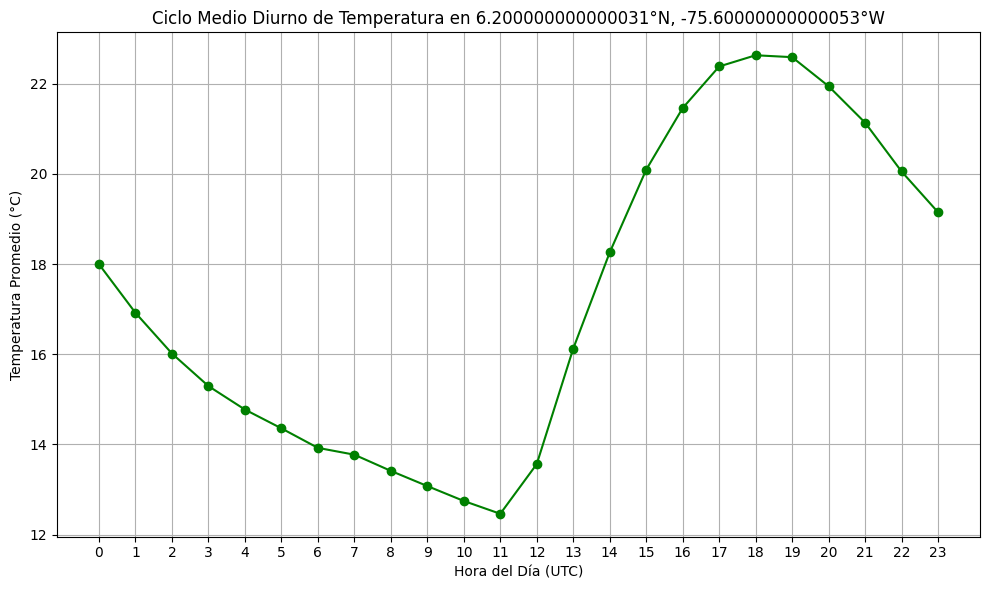

In [13]:
# Para calcular el ciclo diurno promedio:
horas = dates.hour

# Un DataFrame adicional, sólo para el punto P1 escogido previamente:
df_diurnal = pd.DataFrame({'hora': horas, 'temperatura': t2m_ts_p1})

# Calcular el promedio de temperaturas, para cada hora del día por separado
t2m_dlcy_p1 = df_diurnal.groupby('hora')['temperatura'].mean().reset_index()

# Plot the mean diurnal cycle
plt.figure(figsize=(10, 6))
plt.plot(t2m_dlcy_p1['hora'], t2m_dlcy_p1['temperatura'], marker='o', linestyle='-', color='green')
plt.title(f'Ciclo Medio Diurno de Temperatura en {lat1_e5l}°N, {lon1_e5l}°W')
plt.xlabel('Hora del Día (UTC)')
plt.ylabel('Temperatura Promedio (°C)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# En esta figura se ve muy claramente que la hora del máximo de temperatura
# no es numéricamente la que uno esperaría, con un máximo a las 18:00 (UTC).

# Para estudiar variables de superficie, y cuando se trata de una región pequeña (en longitudes),
# es mejor pasarse a hora local.

In [14]:
# Un DataFrame adicional, sólo para el punto P1 escogido previamente:
df_t2m_p1 = pd.DataFrame({'hora': horas, 'temperatura': t2m_ts_p1})
df_t2m_p1

,hora,temperatura
0,0,18.193512
1,1,17.103668
2,2,16.133453
3,3,15.391022
4,4,14.647614
...,...,...
739,19,23.810944
740,20,23.689362
741,21,22.959381
742,22,21.263336


In [15]:
# Hacemos el cambio a hora local
df_t2m_p1_lt = df_t2m_p1.copy()
df_t2m_p1_lt['hora'] = (df_t2m_p1_lt['hora'] - 5) % 24
df_t2m_p1_lt

,hora,temperatura
0,19,18.193512
1,20,17.103668
2,21,16.133453
3,22,15.391022
4,23,14.647614
...,...,...
739,14,23.810944
740,15,23.689362
741,16,22.959381
742,17,21.263336


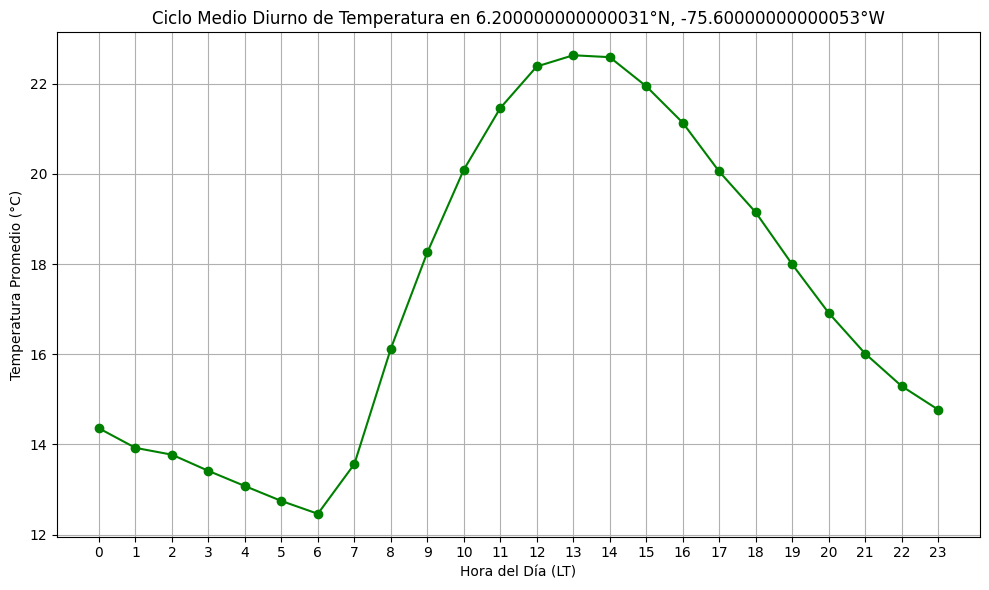

In [16]:
# Calcular el promedio de temperaturas, para cada hora del día por separado
t2m_dlcy_p1_lt = df_t2m_p1_lt.groupby('hora')['temperatura'].mean().reset_index()

# Plot the mean diurnal cycle
plt.figure(figsize=(10, 6))
plt.plot(t2m_dlcy_p1['hora'], t2m_dlcy_p1_lt['temperatura'], marker='o', linestyle='-', color='green')
plt.title(f'Ciclo Medio Diurno de Temperatura en {lat1_e5l}°N, {lon1_e5l}°W')
plt.xlabel('Hora del Día (LT)')
plt.ylabel('Temperatura Promedio (°C)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Finalmente, re-hacemos los pasos anteriores, para dos puntos, incluyendo la conversión a hora local:

# Primero: escoger las horas:
horas = dates.hour

# Luego, vamos por los puntos ...

# Primer, escoger un lugar de interés:
lat1 = 6.24 # Latitud
lon1 = -75.58 # Longitud
# El siguiente bloque es para encontrar las coordenadas del grid más cercanas,
# y extraer la serie de tiempo:
# Latitudes y longitudes más cercanas al punto de interés:
lat1_idx = np.abs(lat_t2m.values - lat1).argmin()
lon1_idx = np.abs(lon_t2m.values - lon1).argmin()
# Latitud y longitud exacta en el grid de ERA5-land
lat1_e5l = lat_t2m.values[lat1_idx]
lon1_e5l = lon_t2m.values[lon1_idx]
# Serie de tiempo para el punto 1 seleccionado
t2m_ts_p1 = t2m[:, lat1_idx, lon1_idx]
# Un DataFrame adicional, sólo para el punto P1 escogido previamente:
df_t2m_p1 = pd.DataFrame({'hora': horas, 'temperatura': t2m_ts_p1})
df_t2m_p1_lt = df_t2m_p1.copy()
df_t2m_p1_lt['hora'] = (df_t2m_p1_lt['hora'] - 5) % 24 # Pasando a hora local: LT = UTC - 5

# Primer, escoger un SEGUNDO lugar de interés:
lat2 = 6.49 # Latitud
lon2 = -74.40 # Longitud
# El siguiente bloque es para encontrar las coordenadas del grid más cercanas,
# y extraer la serie de tiempo:
# Latitudes y longitudes más cercanas al punto de interés:
lat2_idx = np.abs(lat_t2m.values - lat2).argmin()
lon2_idx = np.abs(lon_t2m.values - lon2).argmin()
# Latitud y longitud exacta en el grid de ERA5-land
lat2_e5l = lat_t2m.values[lat2_idx]
lon2_e5l = lon_t2m.values[lon2_idx]
# Serie de tiempo para el punto 1 seleccionado
t2m_ts_p2 = t2m[:, lat2_idx, lon2_idx]
# Un DataFrame adicional, sólo para el punto P1 escogido previamente:
df_t2m_p2 = pd.DataFrame({'hora': horas, 'temperatura': t2m_ts_p2})
df_t2m_p2_lt = df_t2m_p2.copy()
df_t2m_p2_lt['hora'] = (df_t2m_p2_lt['hora'] - 5) % 24 # Pasando a hora local: LT = UTC - 5



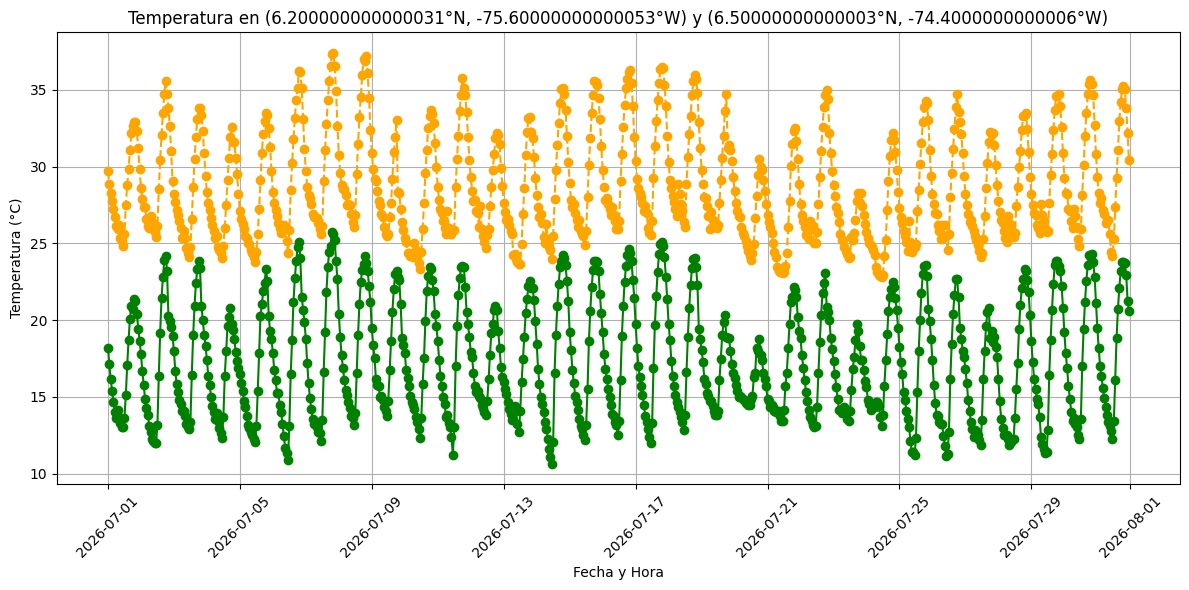

In [18]:
# Series de tiempo de ambos puntos:
# Graficar serie de tiempo
plt.figure(figsize=(12, 6))
plt.plot(dates, df_t2m_p1_lt.temperatura, marker='o', linestyle='-', color='green')
plt.plot(dates, df_t2m_p2_lt.temperatura, marker='o', linestyle='--', color='orange')
plt.title(f'Temperatura en ({lat1_e5l}°N, {lon1_e5l}°W) y ({lat2_e5l}°N, {lon2_e5l}°W)')
plt.xlabel('Fecha y Hora')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

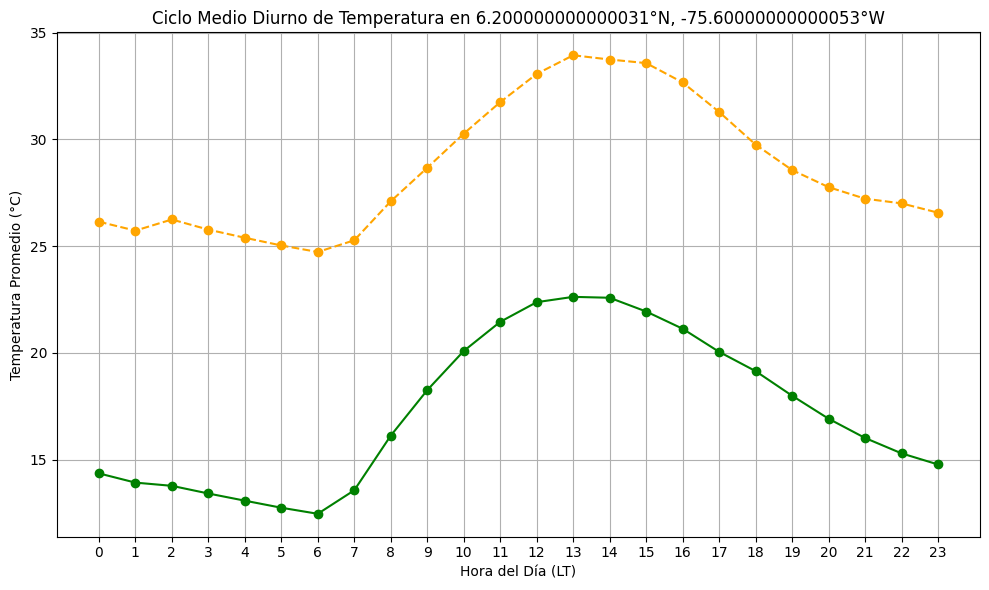

In [19]:
# Finalmente, se grafican ambos ciclos diurnos.
# Calcular el promedio de temperaturas, para cada hora del día por separado
t2m_dlcy_p1_lt = df_t2m_p1_lt.groupby('hora')['temperatura'].mean().reset_index()
t2m_dlcy_p2_lt = df_t2m_p2_lt.groupby('hora')['temperatura'].mean().reset_index()

# Plot the mean diurnal cycle
plt.figure(figsize=(10, 6))
plt.plot(t2m_dlcy_p1_lt['hora'], t2m_dlcy_p1_lt['temperatura'], marker='o', linestyle='-', color='green')
plt.plot(t2m_dlcy_p2_lt['hora'], t2m_dlcy_p2_lt['temperatura'], marker='o', linestyle='--', color='orange')
plt.title(f'Ciclo Medio Diurno de Temperatura en {lat1_e5l}°N, {lon1_e5l}°W')
plt.xlabel('Hora del Día (LT)')
plt.ylabel('Temperatura Promedio (°C)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on the x-axis
plt.grid(True)
plt.tight_layout()
plt.show()